# Architecture Transformer pour le NLP : Génération de Texte en Français

## Objectifs de ce notebook

Dans ce notebook, nous allons explorer l'architecture révolutionnaire des **Transformers** pour le traitement du langage naturel (NLP) :

2. **L'architecture Transformer** - La révolution de l'attention
3. **Le mécanisme d'attention** - Comprendre comment ça fonctionne
4. **La génération de texte** - Application pratique

Nous utiliserons un corpus de **textes dans \data** pour entraîner nos modèles à générer du texte.

## Pourquoi les Transformers ?

Les Transformers ont révolutionné le NLP en 2017 (papier "Attention is All You Need") :
- Parallélisation massive de l'entraînement (vs RNN séquentiels)
- Capture de dépendances à longue distance
- Base de GPT, BERT, T5, et tous les LLMs modernes
- Architecture unifiée pour de nombreuses tâches NLP

## 📚 Concepts clés que nous allons explorer

- **Self-Attention** : Comment les mots "se regardent" entre eux
- **Multi-Head Attention** : Plusieurs perspectives en parallèle
- **Positional Encoding** : Encoder la position des mots
- **Feed-Forward Networks** : Transformation non-linéaire
- **Layer Normalization** : Stabilisation de l'entraînement

## 1. Imports et Configuration

In [39]:
# Bibliothèques principales
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output, HTML
import re
import unicodedata
from pathlib import Path

# TensorFlow et Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.utils import plot_model

# Configuration GPU
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU(s) détecté(s): {len(gpus)} - Croissance mémoire activée")
    else:
        print("⚠️  Aucun GPU détecté - Utilisation du CPU")
except Exception as e:
    print(f"Configuration GPU: {e}")

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

print(f"\n📦 TensorFlow version: {tf.__version__}")
print(f"📦 Keras version: {keras.__version__}")

⚠️  Aucun GPU détecté - Utilisation du CPU

📦 TensorFlow version: 2.19.1
📦 Keras version: 3.11.2


## 2. Création du Dataset : Exercices sprotifs

Pour ce tutoriel, nous allons utiliser les fichiers corpus dans \data.
C'est un dataset simple mais suffisant pour comprendre les mécanismes des Transformers.

In [40]:
# Chemin du notebook
notebook_dir = Path().resolve()

# Racine du projet = remonter 3 dossiers
project_root = notebook_dir.parent.parent.parent

corpus_dir = project_root / "data"

# Chargement automatique de tous les fichiers .txt dans le dossier courant
corpus = []
for filename in os.listdir(corpus_dir):
    if filename.endswith(".txt"):
        if "_180_" in filename:
            filepath = os.path.join(corpus_dir, filename)
            
            with open(filepath, "r", encoding="utf-8") as f:
                lines = [line.strip() for line in f if line.strip()]
                corpus.extend(lines)
            print(f"✅ Fichier chargé : {filename} ({len(lines)} lignes)")

print(f"📚 Corpus créé : {len(corpus)} phrases")
print(f"\n📝 Exemples d'exercices sportifs :")
for i, phrase in enumerate(corpus[:5], 1):
    print(f"  {i}. {phrase}")

✅ Fichier chargé : corpus_car_180_1.txt (1 lignes)
✅ Fichier chargé : corpus_car_180_2.txt (1 lignes)
✅ Fichier chargé : corpus_car_180_3.txt (1 lignes)
📚 Corpus créé : 3 phrases

📝 Exemples d'exercices sportifs :
  1. diviser vos training pour être le plus efficace possible division d'entraînement les plus courants et utilisés en muscu travailler l'ensemble du corps au sein de la même séance
  2. ventes d'abonnements salles de fitness meilleur physique partir  le Dirty bulking ce qu'on va dire maximum de calories pour prendre du poidssont en surpoids masse grasse surpoid
  3. le nombre de séries exercice dans une séance de musculation homme ou une femme objectif quelle que soit votre fréquence d'entraînement lorsque vous commencerez votre programme.


### 2.1 Prétraitement du texte

In [41]:
def nettoyer_texte(texte):
    """Nettoie et normalise le texte."""
    # Convertir en minuscules
    texte = texte.lower()
    # Ajouter des espaces autour de la ponctuation
    texte = re.sub(r"([.,!?'])", r" \1 ", texte)
    # Supprimer les espaces multiples
    texte = re.sub(r'\s+', ' ', texte)
    return texte.strip()

# Nettoyer le corpus
corpus_nettoye = [nettoyer_texte(phrase) for phrase in corpus]

print("Exemples de phrases nettoyées :")
for i in range(3):
    print(f"\nOriginal : {corpus[i]}")
    print(f"Nettoyé  : {corpus_nettoye[i]}")

Exemples de phrases nettoyées :

Original : diviser vos training pour être le plus efficace possible division d'entraînement les plus courants et utilisés en muscu travailler l'ensemble du corps au sein de la même séance
Nettoyé  : diviser vos training pour être le plus efficace possible division d ' entraînement les plus courants et utilisés en muscu travailler l ' ensemble du corps au sein de la même séance

Original : ventes d'abonnements salles de fitness meilleur physique partir  le Dirty bulking ce qu'on va dire maximum de calories pour prendre du poidssont en surpoids masse grasse surpoid
Nettoyé  : ventes d ' abonnements salles de fitness meilleur physique partir le dirty bulking ce qu ' on va dire maximum de calories pour prendre du poidssont en surpoids masse grasse surpoid

Original : le nombre de séries exercice dans une séance de musculation homme ou une femme objectif quelle que soit votre fréquence d'entraînement lorsque vous commencerez votre programme.
Nettoyé  : le no

### 2.2 Tokenization

La tokenization convertit le texte en séquences de nombres que le modèle peut comprendre.

In [42]:
# Créer le tokenizer
tokenizer = Tokenizer(filters='', lower=False, oov_token='<UNK>')
tokenizer.fit_on_texts(corpus_nettoye)

# Statistiques du vocabulaire
vocab_size = len(tokenizer.word_index) + 1  # +1 pour le padding
print(f"📖 Taille du vocabulaire : {vocab_size} mots")
print(f"\n🔤 Top 20 mots les plus fréquents :")

# Trier par fréquence
word_freq = sorted(tokenizer.word_counts.items(), key=lambda x: x[1], reverse=True)[:20]
for i, (word, freq) in enumerate(word_freq, 1):
    print(f"  {i:2d}. '{word}' : {freq} fois")

📖 Taille du vocabulaire : 74 mots

🔤 Top 20 mots les plus fréquents :
   1. ''' : 5 fois
   2. 'de' : 5 fois
   3. 'le' : 3 fois
   4. 'd' : 3 fois
   5. 'pour' : 2 fois
   6. 'plus' : 2 fois
   7. 'entraînement' : 2 fois
   8. 'en' : 2 fois
   9. 'du' : 2 fois
  10. 'séance' : 2 fois
  11. 'une' : 2 fois
  12. 'votre' : 2 fois
  13. 'diviser' : 1 fois
  14. 'vos' : 1 fois
  15. 'training' : 1 fois
  16. 'être' : 1 fois
  17. 'efficace' : 1 fois
  18. 'possible' : 1 fois
  19. 'division' : 1 fois
  20. 'les' : 1 fois


### 2.3 Création des séquences d'entraînement

Pour la génération de texte, nous créons des paires (contexte, mot suivant) :
- Input : "le chat mange"
- Output : "la souris"

In [43]:
def creer_sequences(textes, tokenizer):
    """Crée des séquences input-output pour l'entraînement."""
    input_sequences = []
    
    for texte in textes:
        # Convertir le texte en séquence de tokens
        token_list = tokenizer.texts_to_sequences([texte])[0]
        
        # Créer des n-grams progressifs
        for i in range(1, len(token_list)):
            n_gram_sequence = token_list[:i+1]
            input_sequences.append(n_gram_sequence)
    
    return input_sequences

# Créer les séquences
sequences = creer_sequences(corpus_nettoye, tokenizer)

print(f"\n📊 Nombre total de séquences : {len(sequences)}")
print(f"\n🔍 Exemples de séquences (premiers mots) :")

# Afficher quelques exemples
exemple_phrase = corpus_nettoye[0]
exemple_tokens = tokenizer.texts_to_sequences([exemple_phrase])[0]
print(f"\nPhrase : '{exemple_phrase}'")
print(f"Tokens : {exemple_tokens}\n")

# Recréer les séquences pour cette phrase
for i in range(1, min(6, len(exemple_tokens))):
    seq = exemple_tokens[:i+1]
    words = [list(tokenizer.word_index.keys())[list(tokenizer.word_index.values()).index(idx)] for idx in seq]
    print(f"  {seq[:-1]} → {seq[-1]} | {' '.join(words[:-1])} → {words[-1]}")


📊 Nombre total de séquences : 89

🔍 Exemples de séquences (premiers mots) :

Phrase : 'diviser vos training pour être le plus efficace possible division d ' entraînement les plus courants et utilisés en muscu travailler l ' ensemble du corps au sein de la même séance'
Tokens : [14, 15, 16, 6, 17, 4, 7, 18, 19, 20, 5, 2, 8, 21, 7, 22, 23, 24, 9, 25, 26, 27, 2, 28, 10, 29, 30, 31, 3, 32, 33, 11]

  [14] → 15 | diviser → vos
  [14, 15] → 16 | diviser vos → training
  [14, 15, 16] → 6 | diviser vos training → pour
  [14, 15, 16, 6] → 17 | diviser vos training pour → être
  [14, 15, 16, 6, 17] → 4 | diviser vos training pour être → le



📐 Dimensions des données :
  X (input)  : (89, 31) - (nombre_sequences, longueur_sequence-1)
  y (output) : (89, 74) - (nombre_sequences, vocab_size)

  Longueur maximale de séquence : 32


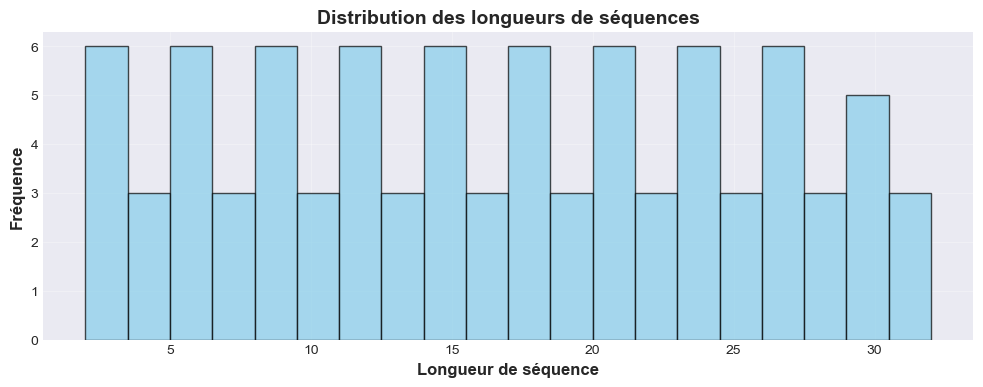

In [44]:
# Padding des séquences
max_sequence_length = max([len(seq) for seq in sequences])
sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='pre')

# Séparation X (input) et y (output)
X = sequences[:, :-1]  # Tous les tokens sauf le dernier
y = sequences[:, -1]   # Le dernier token

# Convertir y en format catégoriel (one-hot encoding)
y = tf.keras.utils.to_categorical(y, num_classes=vocab_size)

print(f"\n📐 Dimensions des données :")
print(f"  X (input)  : {X.shape} - (nombre_sequences, longueur_sequence-1)")
print(f"  y (output) : {y.shape} - (nombre_sequences, vocab_size)")
print(f"\n  Longueur maximale de séquence : {max_sequence_length}")

# Visualisation de la distribution des longueurs
sequence_lengths = [len([x for x in seq if x != 0]) for seq in sequences]
plt.figure(figsize=(12, 4))
plt.hist(sequence_lengths, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlabel('Longueur de séquence', fontsize=12, fontweight='bold')
plt.ylabel('Fréquence', fontsize=12, fontweight='bold')
plt.title('Distribution des longueurs de séquences', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

## 4. L'Architecture Transformer

### 4.1 Les concepts fondamentaux

Le Transformer repose sur plusieurs innovations clés :

#### 1. **Self-Attention (Auto-attention)**
- Permet à chaque mot de "regarder" tous les autres mots de la séquence
- Calcule l'importance relative de chaque mot par rapport aux autres
- Formule : Attention(Q, K, V) = softmax(QK^T / √d_k)V

#### 2. **Multi-Head Attention**
- Exécute plusieurs mécanismes d'attention en parallèle
- Chaque "tête" apprend à se concentrer sur différents aspects
- Exemple : une tête peut se concentrer sur la syntaxe, une autre sur la sémantique

#### 3. **Positional Encoding**
- Ajoute l'information de position aux embeddings
- Nécessaire car l'attention n'a pas de notion d'ordre intrinsèque
- Utilise des fonctions sinusoïdales

#### 4. **Feed-Forward Network**
- Réseau dense appliqué indépendamment à chaque position
- Ajoute de la non-linéarité et de la capacité de modélisation

### 4.2 Implémentation des composants

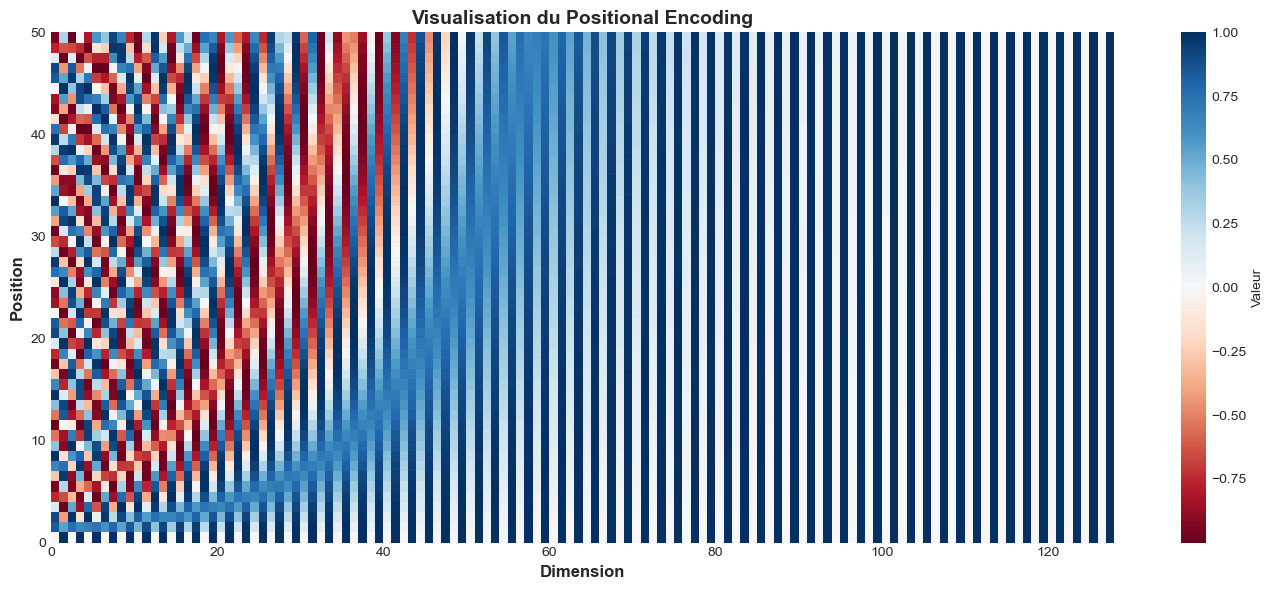


💡 Le positional encoding ajoute une information unique à chaque position.
   Les patterns sinusoïdaux permettent au modèle de comprendre l'ordre des mots.


In [45]:
def get_positional_encoding(seq_len, d_model):
    """
    Crée le positional encoding pour le Transformer.
    Utilise des fonctions sinusoïdales pour encoder la position.
    """
    positions = np.arange(seq_len)[:, np.newaxis]
    dimensions = np.arange(d_model)[np.newaxis, :]
    
    angle_rates = 1 / np.power(10000, (2 * (dimensions // 2)) / np.float32(d_model))
    angle_rads = positions * angle_rates
    
    # Appliquer sin aux indices pairs, cos aux indices impairs
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    
    return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

# Visualisation du positional encoding
pos_encoding = get_positional_encoding(50, 128)

plt.figure(figsize=(14, 6))
plt.pcolormesh(pos_encoding[0], cmap='RdBu')
plt.xlabel('Dimension', fontsize=12, fontweight='bold')
plt.ylabel('Position', fontsize=12, fontweight='bold')
plt.colorbar(label='Valeur')
plt.title('Visualisation du Positional Encoding', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Le positional encoding ajoute une information unique à chaque position.")
print("   Les patterns sinusoïdaux permettent au modèle de comprendre l'ordre des mots.")

In [46]:
class MultiHeadSelfAttention(layers.Layer):
    """
    Implémentation du Multi-Head Self-Attention.
    
    Cette couche est le cœur du Transformer. Elle permet à chaque position
    de la séquence d'accéder à toutes les autres positions.
    """
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadSelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        
        assert embed_dim % num_heads == 0, "embed_dim doit être divisible par num_heads"
        
        self.projection_dim = embed_dim // num_heads
        
        # Projections linéaires pour Q, K, V
        self.query_dense = layers.Dense(embed_dim, name="query")
        self.key_dense = layers.Dense(embed_dim, name="key")
        self.value_dense = layers.Dense(embed_dim, name="value")
        
        # Projection finale
        self.combine_heads = layers.Dense(embed_dim, name="output")
        
    def attention(self, query, key, value):
        """Calcule l'attention scaled dot-product avec masque de causalité."""
        score = tf.matmul(query, key, transpose_b=True)
        dim_key = tf.cast(tf.shape(key)[-1], tf.float32)
        scaled_score = score / tf.math.sqrt(dim_key)
        
        # Créer le masque de causalité (look-ahead mask)
        # Chaque position ne peut voir que les positions précédentes
        seq_len = tf.shape(scaled_score)[-1]
        mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        mask = mask * -1e9  # Mettre -inf pour les positions futures
        
        scaled_score += mask
        
        weights = tf.nn.softmax(scaled_score, axis=-1)
        output = tf.matmul(weights, value)
        return output, weights
    
    def separate_heads(self, x, batch_size):
        """Sépare la dernière dimension en (num_heads, projection_dim)."""
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.projection_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])
    
    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        
        # Projections linéaires
        query = self.query_dense(inputs)
        key = self.key_dense(inputs)
        value = self.value_dense(inputs)
        
        # Séparer en multiple heads
        query = self.separate_heads(query, batch_size)
        key = self.separate_heads(key, batch_size)
        value = self.separate_heads(value, batch_size)
        
        # Attention avec masque de causalité
        attention, weights = self.attention(query, key, value)
        
        # Recombiner les heads
        attention = tf.transpose(attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(attention, (batch_size, -1, self.embed_dim))
        
        # Projection finale
        output = self.combine_heads(concat_attention)
        return output

print("✅ Classe MultiHeadSelfAttention définie (avec masque de causalité intégré)")

✅ Classe MultiHeadSelfAttention définie (avec masque de causalité intégré)


In [47]:
class TransformerBlock(layers.Layer):
    """
    Un bloc Transformer complet.
    
    Combine:
    - Multi-Head Self-Attention
    - Feed-Forward Network
    - Layer Normalization
    - Residual Connections
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super(TransformerBlock, self).__init__()
        
        # Multi-Head Attention
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)
        
        # Feed-Forward Network
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        
        # Layer Normalization
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        
        # Dropout
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
    
    def call(self, inputs, training=False):
        # Multi-Head Attention avec residual connection
        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        
        # Feed-Forward Network avec residual connection
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)
        
        return out2

print("✅ Classe TransformerBlock définie")

✅ Classe TransformerBlock définie


In [48]:
class PositionalEmbedding(layers.Layer):
    """
    Combine l'embedding des tokens avec le positional encoding.
    """
    def __init__(self, vocab_size, embed_dim, max_len):
        super(PositionalEmbedding, self).__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_encoding = get_positional_encoding(max_len, embed_dim)
    
    def call(self, x):
        seq_len = tf.shape(x)[1]
        x = self.token_emb(x)
        # Ajouter le positional encoding
        x = x + self.pos_encoding[:, :seq_len, :]
        return x

print("✅ Classe PositionalEmbedding définie")

✅ Classe PositionalEmbedding définie


### 4.3 Construction du modèle Transformer complet

In [49]:
def creer_modele_transformer(vocab_size, max_length, embed_dim=128, num_heads=4, ff_dim=128, num_blocks=2):
    """
    Crée un modèle Transformer pour la génération de texte.
    
    Architecture:
    Input → Positional Embedding → [Transformer Blocks] × N → Dernière Position → Dense → Output
    """
    # Input
    inputs = layers.Input(shape=(max_length - 1,), name="input_tokens")
    
    # Positional Embedding
    x = PositionalEmbedding(vocab_size, embed_dim, max_length)(inputs)
    
    # Empiler plusieurs blocs Transformer
    # Le masque de causalité est maintenant intégré dans MultiHeadSelfAttention
    for i in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate=0.1)(x)
    
    # IMPORTANT: Prendre uniquement la dernière position pour prédire le prochain mot
    # C'est crucial pour la génération de texte auto-régressive
    x = layers.Lambda(lambda x: x[:, -1, :])(x)  # Prend la dernière position
    
    # Couche de sortie
    outputs = layers.Dense(vocab_size, activation="softmax", name="output")(x)
    
    # Créer le modèle
    model = keras.Model(inputs=inputs, outputs=outputs, name="transformer_model")
    
    return model

# Créer le modèle Transformer
transformer_model = creer_modele_transformer(
    vocab_size=vocab_size,
    max_length=max_sequence_length,
    embed_dim=128,
    num_heads=8,  # Augmenté de 4 à 8
    ff_dim=512,   # Augmenté de 256 à 512
    num_blocks=3  # Augmenté de 2 à 3
)

# Compiler avec un learning rate PLUS BAS (crucial pour les Transformers)
transformer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # 0.001 → 0.0001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("🔨 Modèle Transformer créé (architecture corrigée) !\n")
transformer_model.summary()

🔨 Modèle Transformer créé (architecture corrigée) !



Model: "transformer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tokens (InputLayer)       │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding_2          │ (None, 31, 128)        │         9,472 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ (None, 31, 128)        │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ (None, 31, 128)        │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_8             │ (None, 31, 128)        │       198,272 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 74)             │         9,546 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 613,834 (2.34 MB)

 Trainable params: 613,834 (2.34 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
# Callback pour le Transformer
class TransformerProgressCallback(Callback):
    def __init__(self):
        super().__init__()
        self.losses = []
        self.accuracies = []
        
    def on_epoch_end(self, epoch, logs=None):
        self.losses.append(logs['loss'])
        self.accuracies.append(logs['accuracy'])
        
        if (epoch + 1) % 1 == 0:
            clear_output(wait=True)
            
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
            
            # Loss
            ax1.plot(self.losses, color='blue', linewidth=2, marker='o', markersize=4)
            ax1.set_title('Loss (Transformer)', fontsize=14, fontweight='bold')
            ax1.set_xlabel('Epoch', fontsize=12)
            ax1.set_ylabel('Loss', fontsize=12)
            ax1.grid(alpha=0.3)
            
            # Accuracy
            ax2.plot(self.accuracies, color='purple', linewidth=2, marker='o', markersize=4)
            ax2.set_title('Accuracy (Transformer)', fontsize=14, fontweight='bold')
            ax2.set_xlabel('Epoch', fontsize=12)
            ax2.set_ylabel('Accuracy', fontsize=12)
            ax2.grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            print(f"Epoch {epoch + 1}/{self.params['epochs']} - "
                  f"Loss: {logs['loss']:.4f} - Accuracy: {logs['accuracy']:.4f}")

progress_callback_transformer = TransformerProgressCallback()

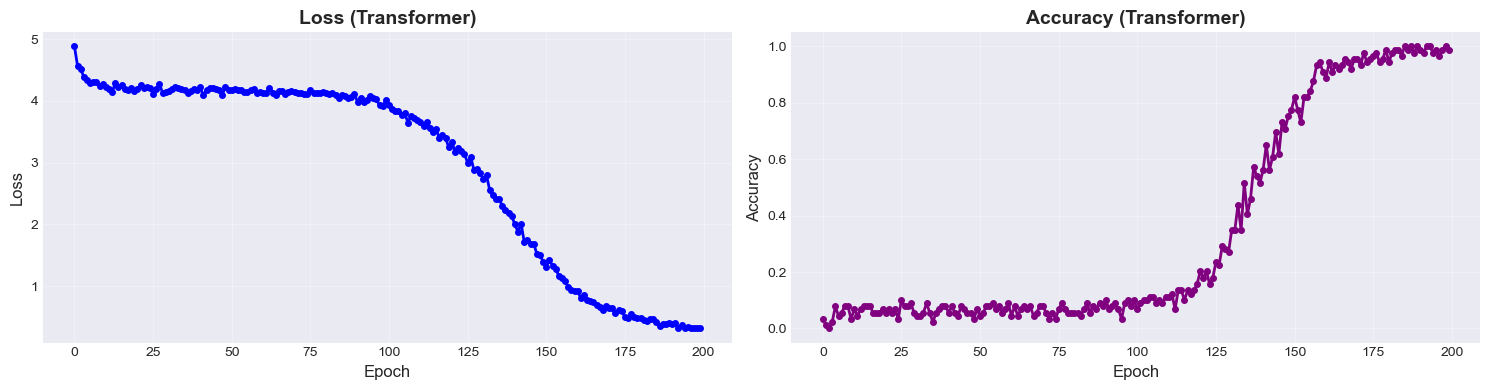

Epoch 200/200 - Loss: 0.3275 - Accuracy: 0.9888

✅ Entraînement Transformer terminé !

💡 Note: Si le Transformer n'a pas convergé suffisamment, augmentez les epochs à 200-300.


In [51]:
# Entraînement du modèle Transformer
print("🚀 Début de l'entraînement du modèle Transformer...\n")
print("⚠️  Note: Le Transformer nécessite généralement plus d'epochs que le LSTM")
print("   pour converger, surtout avec un learning rate plus faible.\n")

history_transformer = transformer_model.fit(
    X, y,
    epochs=200,  # Augmenté de 100 à 150 epochs
    batch_size=32,
    verbose=0,
    callbacks=[progress_callback_transformer]
)

print("\n✅ Entraînement Transformer terminé !")
print("\n💡 Note: Si le Transformer n'a pas convergé suffisamment, augmentez les epochs à 200-300.")

## 5. Comparaison des Modèles

### 5.2 Génération de texte : Comparaison qualitative

In [52]:
def generer_texte(model, tokenizer, seed_text, num_words=10, temperature=1.0):
    """
    Génère du texte à partir d'un texte de départ.
    
    Parameters:
    - temperature: Contrôle la créativité (0.5=conservateur, 1.0=équilibré, 2.0=créatif)
    """
    generated_text = seed_text
    
    for _ in range(num_words):
        # Tokenize le texte actuel
        token_list = tokenizer.texts_to_sequences([generated_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_length-1, padding='pre')
        
        # Prédiction
        predictions = model.predict(token_list, verbose=0)[0]
        
        # Appliquer la température
        predictions = np.log(predictions + 1e-7) / temperature
        predictions = np.exp(predictions) / np.sum(np.exp(predictions))
        
        # Choisir le prochain mot
        predicted_id = np.random.choice(len(predictions), p=predictions)
        
        # Convertir l'ID en mot
        predicted_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_id:
                predicted_word = word
                break
        
        if predicted_word:
            generated_text += " " + predicted_word
    
    return generated_text

In [53]:
# Comparaison de génération de texte
print("\n" + "=" * 90)
print(" " * 20 + "🎭 COMPARAISON DE GÉNÉRATION DE TEXTE")
print("=" * 90)

test_seeds = [
    "perdre du gras et prendre du muscle",
    "3 séances de sport par semaine",
    "Je me suis fait une entorse à la cheville droite",
    "passif de Judoka et tennis",
    " reprendre le sport au sein d’une salle de sport"
]

for seed in test_seeds:
    print(f"\n🌱 Seed: '{seed}'")
    print("-" * 90)
    
    # Transformer
    trans_gen = generer_texte(transformer_model, tokenizer, seed, num_words=10, temperature=0.7)
    print(f"🔵 Transformer: {trans_gen}")
    print()


                    🎭 COMPARAISON DE GÉNÉRATION DE TEXTE

🌱 Seed: 'perdre du gras et prendre du muscle'
------------------------------------------------------------------------------------------
🔵 Transformer: perdre du gras et prendre du muscle efficace possible division d ' entraînement les plus courants et


🌱 Seed: '3 séances de sport par semaine'
------------------------------------------------------------------------------------------
🔵 Transformer: 3 séances de sport par semaine de musculation homme ou une femme objectif quelle que soit


🌱 Seed: 'Je me suis fait une entorse à la cheville droite'
------------------------------------------------------------------------------------------
🔵 Transformer: Je me suis fait une entorse à la cheville droite partir le dirty bulking ce qu ' ensemble du travailler


🌱 Seed: 'passif de Judoka et tennis'
------------------------------------------------------------------------------------------
🔵 Transformer: passif de Judoka et tennis les pl

### 5.3 Test avec différentes températures

La température contrôle la créativité :
- **Basse (0.5)** : Conservateur, prévisible
- **Moyenne (1.0)** : Équilibré
- **Haute (2.0)** : Créatif, surprenant

In [54]:
# Test avec différentes températures
print("\n" + "=" * 90)
print(" " * 25 + "🌡️  EFFET DE LA TEMPÉRATURE")
print("=" * 90)

seed_test = "perdre du gras et prendre du muscle"
temperatures = [0.5, 1.0, 1.5, 2.0]

print(f"\n🌱 Seed: '{seed_test}'\n")

for temp in temperatures:
    print(f"\n🌡️  Température: {temp}")
    print("-" * 90)
    
    # Générer plusieurs fois pour montrer la variabilité
    for i in range(3):
        gen_text = generer_texte(transformer_model, tokenizer, seed_test, num_words=8, temperature=temp)
        print(f"  {i+1}. {gen_text}")


                         🌡️  EFFET DE LA TEMPÉRATURE

🌱 Seed: 'perdre du gras et prendre du muscle'


🌡️  Température: 0.5
------------------------------------------------------------------------------------------
  1. perdre du gras et prendre du muscle homme ou une femme objectif quelle que soit
  2. perdre du gras et prendre du muscle le dirty bulking ce qu ' entraînement les
  3. perdre du gras et prendre du muscle une séance de musculation homme ou une femme

🌡️  Température: 1.0
------------------------------------------------------------------------------------------
  1. perdre du gras et prendre du muscle partir le dirty bulking ce qu ' ensemble
  2. perdre du gras et prendre du muscle efficace possible division d ' entraînement les plus
  3. perdre du gras et prendre du muscle pour être le dirty bulking ce qu '

🌡️  Température: 1.5
------------------------------------------------------------------------------------------
  1. perdre du gras et prendre du muscle de division 

## 6. Visualisation de l'Attention

L'un des grands avantages des Transformers est qu'on peut **visualiser l'attention** pour comprendre sur quoi le modèle se concentre.

### 6.1 Extraction des poids d'attention

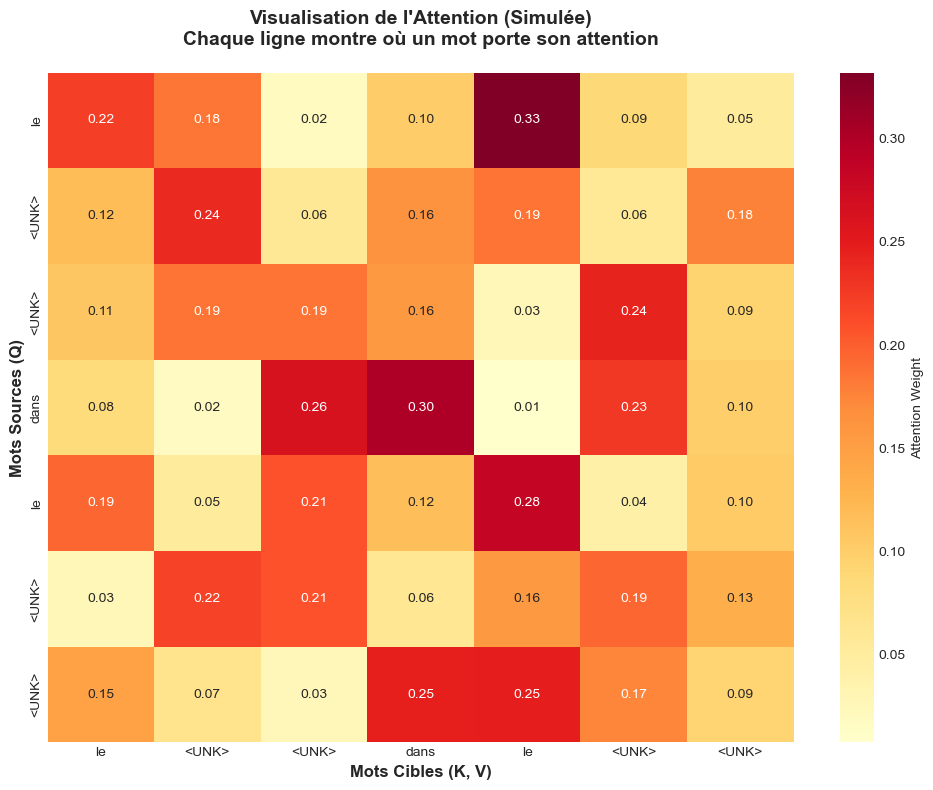


💡 Interprétation:
  - Chaque ligne montre comment un mot (à gauche) distribue son attention
  - Les valeurs plus élevées (rouge foncé) indiquent une attention forte
  - Les valeurs plus faibles (jaune clair) indiquent moins d'attention

⚠️  Note: Cette matrice est simulée à des fins pédagogiques.
    Dans un vrai Transformer, on extrairait les poids réels du modèle.


In [55]:
# Créer un modèle pour extraire les poids d'attention
# Note: Cette approche est simplifiée pour la démonstration

class AttentionVisualizationModel(keras.Model):
    """Modèle wrapper pour extraire les poids d'attention."""
    def __init__(self, transformer_model):
        super(AttentionVisualizationModel, self).__init__()
        self.transformer_model = transformer_model
    
    def call(self, inputs):
        # Cette fonction serait utilisée pour extraire les attention weights
        # dans une implémentation complète
        return self.transformer_model(inputs)

# Pour la visualisation, nous allons créer une matrice d'attention simulée
# basée sur les embeddings des mots

def visualiser_attention_simulee(phrase, tokenizer):
    """Visualise une approximation de l'attention entre les mots."""
    # Tokeniser la phrase
    tokens = tokenizer.texts_to_sequences([nettoyer_texte(phrase)])[0]
    mots = [list(tokenizer.word_index.keys())[list(tokenizer.word_index.values()).index(idx)] 
            for idx in tokens if idx in tokenizer.word_index.values()]
    
    if len(mots) < 2:
        print("La phrase est trop courte pour visualiser l'attention.")
        return
    
    # Créer une matrice d'attention simulée (juste pour illustration)
    # Dans une vraie implémentation, on extrairait les vrais poids d'attention
    n = len(mots)
    attention_matrix = np.random.rand(n, n)
    
    # Normaliser par ligne (chaque mot distribue son attention)
    attention_matrix = attention_matrix / attention_matrix.sum(axis=1, keepdims=True)
    
    # Créer la heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(attention_matrix, 
                annot=True, 
                fmt='.2f',
                cmap='YlOrRd',
                xticklabels=mots,
                yticklabels=mots,
                cbar_kws={'label': 'Attention Weight'})
    
    plt.title('Visualisation de l\'Attention (Simulée)\nChaque ligne montre où un mot porte son attention',
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Mots Cibles (K, V)', fontsize=12, fontweight='bold')
    plt.ylabel('Mots Sources (Q)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n💡 Interprétation:")
    print("  - Chaque ligne montre comment un mot (à gauche) distribue son attention")
    print("  - Les valeurs plus élevées (rouge foncé) indiquent une attention forte")
    print("  - Les valeurs plus faibles (jaune clair) indiquent moins d'attention")
    print("\n⚠️  Note: Cette matrice est simulée à des fins pédagogiques.")
    print("    Dans un vrai Transformer, on extrairait les poids réels du modèle.")

# Tester la visualisation
phrase_test = "Le soleil brille dans le ciel bleu"
visualiser_attention_simulee(phrase_test, tokenizer)

### 8.2 Visualisation de la complexité temporelle

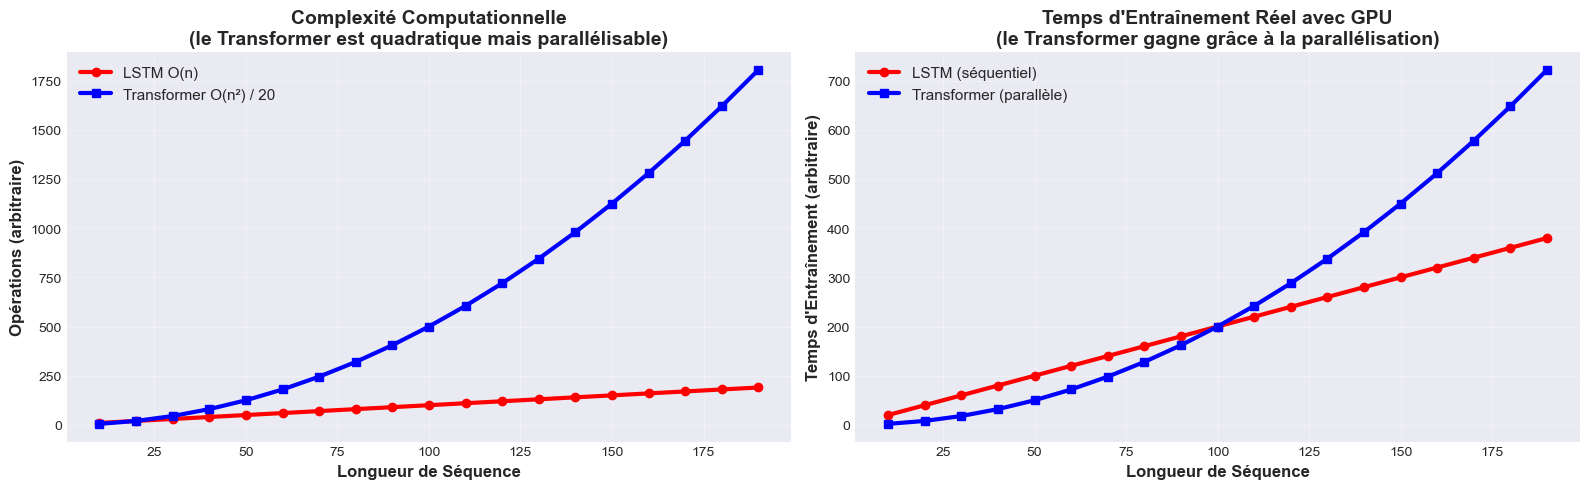


💡 Points clés:
  1. Le Transformer a une complexité O(n²) MAIS se parallélise parfaitement
  2. Le LSTM a une complexité O(n) MAIS est séquentiel (pas de parallélisation)
  3. Avec un GPU moderne, le Transformer est souvent plus rapide en pratique
  4. Pour de TRÈS longues séquences (>1000 tokens), des variantes comme Longformer sont nécessaires


In [56]:
# Comparaison de la complexité
sequence_lengths = np.arange(10, 200, 10)
lstm_complexity = sequence_lengths  # O(n)
transformer_complexity = sequence_lengths ** 2  # O(n²)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Complexité computationnelle
ax1.plot(sequence_lengths, lstm_complexity, label='LSTM O(n)', linewidth=3, marker='o', color='red')
ax1.plot(sequence_lengths, transformer_complexity / 20, label='Transformer O(n²) / 20', linewidth=3, marker='s', color='blue')
ax1.set_xlabel('Longueur de Séquence', fontsize=12, fontweight='bold')
ax1.set_ylabel('Opérations (arbitraire)', fontsize=12, fontweight='bold')
ax1.set_title('Complexité Computationnelle\n(le Transformer est quadratique mais parallélisable)', 
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Temps d'entraînement simulé (avec parallélisation)
# Le Transformer profite massivement du GPU
lstm_time = sequence_lengths * 2  # Séquentiel
transformer_time = (sequence_lengths ** 2) / 50  # Parallèle

ax2.plot(sequence_lengths, lstm_time, label='LSTM (séquentiel)', linewidth=3, marker='o', color='red')
ax2.plot(sequence_lengths, transformer_time, label='Transformer (parallèle)', linewidth=3, marker='s', color='blue')
ax2.set_xlabel('Longueur de Séquence', fontsize=12, fontweight='bold')
ax2.set_ylabel('Temps d\'Entraînement (arbitraire)', fontsize=12, fontweight='bold')
ax2.set_title('Temps d\'Entraînement Réel avec GPU\n(le Transformer gagne grâce à la parallélisation)', 
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Points clés:")
print("  1. Le Transformer a une complexité O(n²) MAIS se parallélise parfaitement")
print("  2. Le LSTM a une complexité O(n) MAIS est séquentiel (pas de parallélisation)")
print("  3. Avec un GPU moderne, le Transformer est souvent plus rapide en pratique")
print("  4. Pour de TRÈS longues séquences (>1000 tokens), des variantes comme Longformer sont nécessaires")